# Exploring the European Soccer Database (SQLite)

This notebook contains code for exploring the ultimate European Soccer database (`database.sqlite`). 

The exact database file should be in your working directory as `database.sqlite` (adjust the path if it's stored under a `data/` folder).

It includes over 25,000 matches, 10,000 players, 11 European Countries with top championships from the 2008 to 2016 seasons, and EA Sports FIFA attributes!

## 1. Connect to the Database
We connect using `sqlite3` and `pandas`. Make sure your database file `database.sqlite` is in the correct directory.

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# =====================================================================
# Database path
# =====================================================================
# Your database is here:
#   C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\database.sqlite

db_path = Path(r"C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\database.sqlite")

# Safety check to prevent SQLite from creating an empty database
if (not db_path.exists()) or db_path.stat().st_size == 0:
    raise FileNotFoundError(
        f"Database not found at: {db_path.resolve()}\n"
        "SQLite may create an empty file if the path is wrong."
    )

# Create the SQLite connection
conn = sqlite3.connect(str(db_path))
print(f"Successfully connected to {db_path} via sqlite3!")

Successfully connected to C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\database.sqlite via sqlite3!


## 2. List Database Tables
Let's see what tables are available in the master SQLite index. We can expect tables for matches, players, teams, leagues, and EA Sports attributes.

In [13]:
# Query the master table for all user table names
tables_query = """
    SELECT name 
    FROM sqlite_master 
    WHERE type='table';
"""
tables_df = pd.read_sql(tables_query, conn)

print("Tables in the SQLite Database:")
display(tables_df)

Tables in the SQLite Database:


,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


## 3. Explore Country and League Data
Before we look at individual matches or players, let's explore what country/league combinations are available in the dataset.

In [14]:
countries_leagues_query = """
    SELECT Country.name as CountryName, 
           League.name as LeagueName 
    FROM League
    JOIN Country ON Country.id = League.country_id;
"""

leagues_df = pd.read_sql(countries_leagues_query, conn)
display(leagues_df)

,CountryName,LeagueName
0,Belgium,Belgium Jupiler League
1,England,England Premier League
2,France,France Ligue 1
3,Germany,Germany 1. Bundesliga
4,Italy,Italy Serie A
5,Netherlands,Netherlands Eredivisie
6,Poland,Poland Ekstraklasa
7,Portugal,Portugal Liga ZON Sagres
8,Scotland,Scotland Premier League
9,Spain,Spain LIGA BBVA


## 4. Analyze Match Data
Next, we can extract the history for European matches. We'll join the `Match` table with the respective target entities (`Country`, `League`, `Team`) to extract readable data. We'll limit it to a few matches to see the structure and also calculate basic stats like total goals.

Latest 10 European Matches:


,id,country_name,league_name,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
0,25945,Switzerland,Switzerland Super League,2015/2016,36,2016-05-25 00:00:00,FC Basel,Grasshopper Club Zürich,0,1
1,25946,Switzerland,Switzerland Super League,2015/2016,36,2016-05-25 00:00:00,Lugano,FC St. Gallen,3,0
2,25947,Switzerland,Switzerland Super League,2015/2016,36,2016-05-25 00:00:00,FC Luzern,FC Sion,2,2
3,25948,Switzerland,Switzerland Super League,2015/2016,36,2016-05-25 00:00:00,FC Thun,BSC Young Boys,0,3
4,25949,Switzerland,Switzerland Super League,2015/2016,36,2016-05-25 00:00:00,FC Zürich,FC Vaduz,3,1


,season,avg_home_goals,avg_away_goals
0,2008/2009,1.505412,1.101924
1,2009/2010,1.541176,1.131269
2,2010/2011,1.548466,1.135276
3,2011/2012,1.572671,1.143789
4,2012/2013,1.550000,1.222699
5,2013/2014,1.578826,1.187995
6,2014/2015,1.520301,1.155489
7,2015/2016,1.543897,1.210764


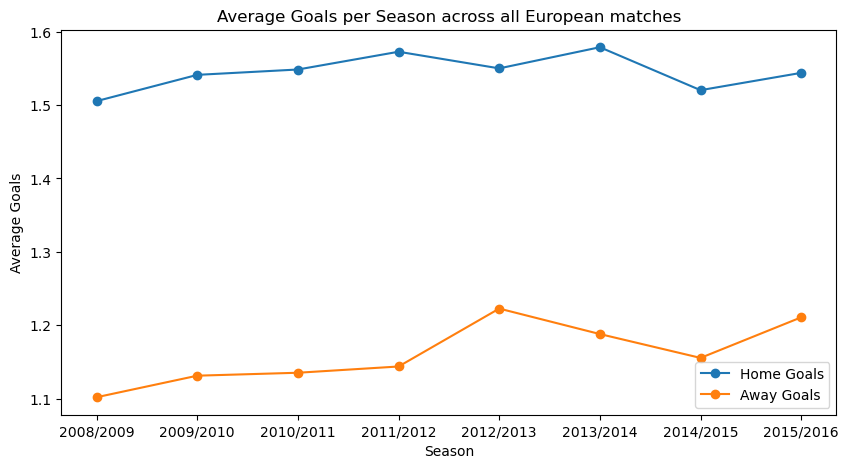

In [15]:
# Basic match results with team names
matches_query = """
    SELECT Match.id, 
           Country.name AS country_name, 
           League.name AS league_name, 
           season, 
           stage, 
           date,
           HT.team_long_name AS home_team,
           AT.team_long_name AS away_team,
           home_team_goal, 
           away_team_goal
    FROM Match
    JOIN Country ON Country.id = Match.country_id
    JOIN League ON League.id = Match.league_id
    LEFT JOIN Team AS HT ON HT.team_api_id = Match.home_team_api_id
    LEFT JOIN Team AS AT ON AT.team_api_id = Match.away_team_api_id
    ORDER BY date DESC
    LIMIT 10;
"""

recent_matches = pd.read_sql(matches_query, conn)
print("Latest 10 European Matches:")
display(recent_matches.head())

# Aggregate goals by season
goals_by_season_query = """
    SELECT season, AVG(home_team_goal) as avg_home_goals, AVG(away_team_goal) as avg_away_goals
    FROM Match 
    GROUP BY season;
"""
goals_by_season = pd.read_sql(goals_by_season_query, conn)
display(goals_by_season)

plt.figure(figsize=(10,5))
plt.plot(goals_by_season['season'], goals_by_season['avg_home_goals'], marker='o', label='Home Goals')
plt.plot(goals_by_season['season'], goals_by_season['avg_away_goals'], marker='o', label='Away Goals')
plt.title('Average Goals per Season across all European matches')
plt.xlabel('Season')
plt.ylabel('Average Goals')
plt.legend()
plt.show()

## 5. Explore Player Attributes
Using the `Player` and `Player_Attributes` tables, we can retrieve details like FIFA ratings spanning from season 2008 to 2016, along with basic attributes like height and weight.

Top 10 Player Attributes instances:


,player_name,height,weight,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate
0,Lionel Messi,170.18,159,2015-12-17 00:00:00,94,94,left,medium,low
1,Lionel Messi,170.18,159,2015-10-16 00:00:00,94,94,left,medium,low
2,Lionel Messi,170.18,159,2015-09-21 00:00:00,94,95,left,medium,low
3,Lionel Messi,170.18,159,2014-04-25 00:00:00,94,97,left,medium,low
4,Lionel Messi,170.18,159,2013-11-15 00:00:00,94,97,left,high,medium
5,Lionel Messi,170.18,159,2013-09-20 00:00:00,94,97,left,high,medium
6,Lionel Messi,170.18,159,2013-03-22 00:00:00,94,97,left,high,medium
7,Lionel Messi,170.18,159,2013-03-08 00:00:00,94,97,left,high,medium
8,Lionel Messi,170.18,159,2013-02-15 00:00:00,94,97,left,high,medium
9,Lionel Messi,170.18,159,2012-08-31 00:00:00,94,96,left,high,medium


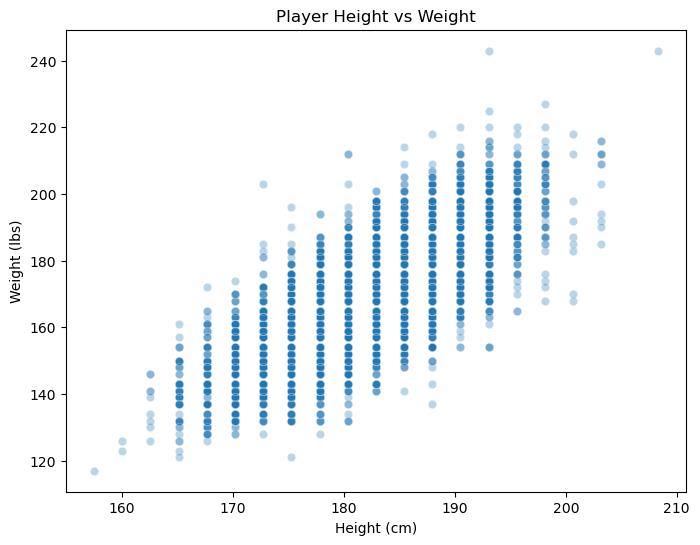

In [16]:
player_query = """
    SELECT P.player_name, 
           P.height, 
           P.weight,
           PA.date,
           PA.overall_rating, 
           PA.potential, 
           PA.preferred_foot,
           PA.attacking_work_rate,
           PA.defensive_work_rate
    FROM Player P
    JOIN Player_Attributes PA ON P.player_api_id = PA.player_api_id
    ORDER BY PA.overall_rating DESC
    LIMIT 10;
"""

top_rated_players = pd.read_sql(player_query, conn)
print("Top 10 Player Attributes instances:")
display(top_rated_players.head(10))

# Basic Player Height & Weight Plot
basic_players_query = """SELECT player_name, height, weight FROM Player;"""
players_df = pd.read_sql(basic_players_query, conn)

plt.figure(figsize=(8,6))
sns.scatterplot(x='height', y='weight', data=players_df, alpha=0.3)
plt.title("Player Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (lbs)")
plt.show()

## 6. Analyze Team Attributes
The `Team_Attributes` table lists tactical settings for the teams from EA Sports' definitions, such as `"Build Up Play Speed"`, passing stats, and team play styles.

In [17]:
team_attrs_query = """
    SELECT T.team_long_name As Team, 
           TA.date,
           TA.buildUpPlaySpeed, 
           TA.buildUpPlaySpeedClass,
           TA.buildUpPlayPassing, 
           TA.buildUpPlayPassingClass,
           TA.chanceCreationPassing,
           TA.chanceCreationShooting
    FROM Team_Attributes TA
    JOIN Team T ON TA.team_api_id = T.team_api_id
    ORDER BY TA.date DESC
    LIMIT 10;
"""

team_attributes_df = pd.read_sql(team_attrs_query, conn)
display(team_attributes_df)

,Team,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayPassing,buildUpPlayPassingClass,chanceCreationPassing,chanceCreationShooting
0,FC Aarau,2015-09-10 00:00:00,47,Balanced,54,Mixed,54,64
1,Aberdeen,2015-09-10 00:00:00,59,Balanced,53,Mixed,51,63
2,AC Ajaccio,2015-09-10 00:00:00,59,Balanced,52,Mixed,48,52
3,Milan,2015-09-10 00:00:00,48,Balanced,52,Mixed,66,69
4,Académica de Coimbra,2015-09-10 00:00:00,53,Balanced,44,Mixed,55,60
5,ADO Den Haag,2015-09-10 00:00:00,56,Balanced,66,Mixed,55,38
6,Ajax,2015-09-10 00:00:00,35,Balanced,39,Mixed,58,30
7,UD Almería,2015-09-10 00:00:00,46,Balanced,65,Mixed,57,40
8,RSC Anderlecht,2015-09-10 00:00:00,52,Balanced,51,Mixed,60,47
9,Angers SCO,2015-09-10 00:00:00,48,Balanced,50,Mixed,40,48


## 7. Explore Betting Odds
The Match table contains dozens of columns representing odds for different outcomes (Home Win `B365H`, Draw `B365D`, Away Win `B365A` etc.). Let's look at the distribution.

Betting Odds summary from Bet365:


,home_team_goal,away_team_goal,HomeWinOdds,DrawOdds,AwayWinOdds
count,22592.000000,22592.000000,22592.000000,22592.000000,22592.000000
mean,1.549398,1.165767,2.628818,3.839684,4.662222
std,1.300920,1.146870,1.794463,1.118269,3.730104
min,0.000000,0.000000,1.040000,1.400000,1.080000
25%,1.000000,0.000000,1.670000,3.300000,2.500000
50%,1.000000,1.000000,2.100000,3.500000,3.500000
75%,2.000000,2.000000,2.800000,4.000000,5.250000
max,10.000000,9.000000,26.000000,17.000000,51.000000


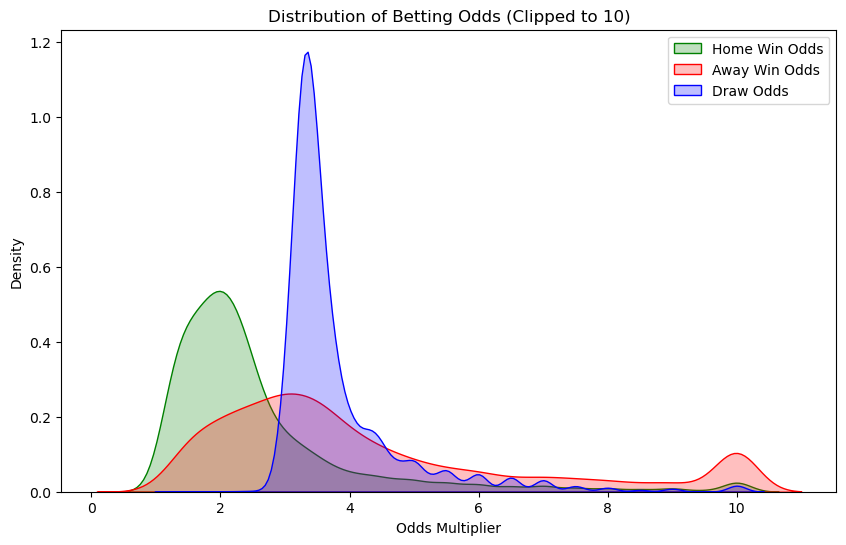

In [18]:
odds_query = """
    SELECT home_team_goal, 
           away_team_goal,
           B365H AS HomeWinOdds, 
           B365D AS DrawOdds, 
           B365A AS AwayWinOdds
    FROM Match 
    WHERE B365H IS NOT NULL;
"""

odds_df = pd.read_sql(odds_query, conn)

print("Betting Odds summary from Bet365:")
display(odds_df.describe())

# A quick visualization to show how much larger Away Odds frequently are compared to Home Odds
plt.figure(figsize=(10,6))
sns.kdeplot(odds_df['HomeWinOdds'].clip(upper=10), label='Home Win Odds', fill=True, color='green')
sns.kdeplot(odds_df['AwayWinOdds'].clip(upper=10), label='Away Win Odds', fill=True, color='red')
sns.kdeplot(odds_df['DrawOdds'].clip(upper=10), label='Draw Odds', fill=True, color='blue')
plt.title("Distribution of Betting Odds (Clipped to 10)")
plt.xlabel("Odds Multiplier")
plt.legend()
plt.show()

## 8. MBML Baselines: Naïve Match Outcome Model
For a Model-Based Machine Learning project, it is crucial to establish the base rates. The simplest predictive baseline model (the null model) in soccer matches is to predict the most common outcome every time (typically a Home Win). Let's calculate the global outcome probabilities across our entire dataset.

Global Base Probabilities for Match Outcomes:


match_outcome
Home Win    45.871666
Away Win    28.738597
Draw        25.389738
Name: proportion, dtype: float64


The simplest baseline model (always predicting 'Home Win'): 45.87% Accuracy


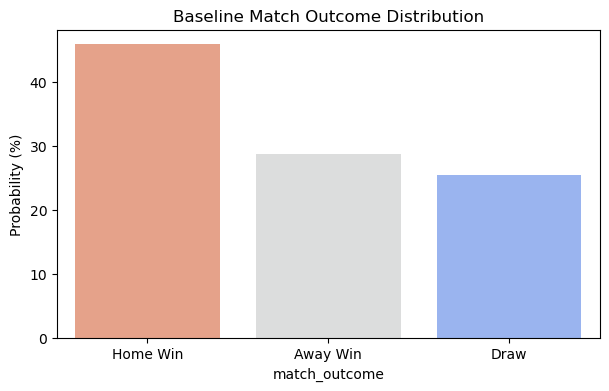

In [19]:
# Query the raw match outcome distribution
outcomes_query = """
    SELECT home_team_goal, away_team_goal,
           CASE 
               WHEN home_team_goal > away_team_goal THEN 'Home Win'
               WHEN home_team_goal = away_team_goal THEN 'Draw'
               ELSE 'Away Win'
           END AS match_outcome
    FROM Match;
"""
outcomes_df = pd.read_sql(outcomes_query, conn)

# Calculate the base probabilities
base_rates = outcomes_df['match_outcome'].value_counts(normalize=True) * 100

print("Global Base Probabilities for Match Outcomes:")
display(base_rates)

highest_prob_class = base_rates.idxmax()
highest_prob_val = base_rates.max()
print(f"\nThe simplest baseline model (always predicting '{highest_prob_class}'): {highest_prob_val:.2f}% Accuracy")

# Plot distribution
plt.figure(figsize=(7, 4))
sns.barplot(x=base_rates.index, y=base_rates.values, hue=base_rates.index, legend=False, palette='coolwarm_r')
plt.title('Baseline Match Outcome Distribution')
plt.ylabel('Probability (%)')
plt.show()

## 9. Baseline Correlation: Do Betting Odds Predict Outcomes?
In many sports modeling setups, bookmaker odds (implied probability) serve as the strongest pre-existing baseline benchmark against which new Machine Learning models are compared. We compute a simple correlation to demonstrate the relationship between match outcomes (encoded numerically) and the B365 odds.


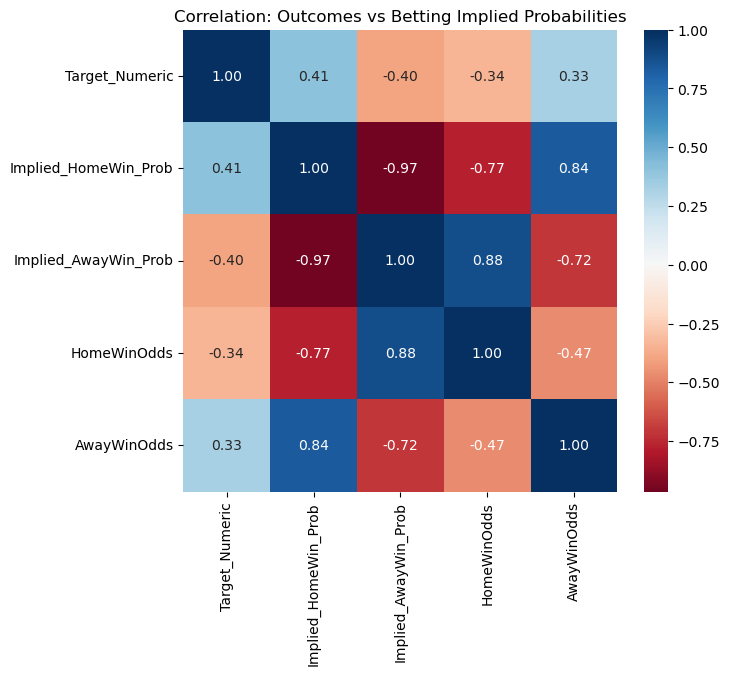

In [20]:
import numpy as np

baseline_model_df = odds_df.copy()

# Simple numeric mapping for visualization (1 = Home Win, 0.5 = Draw, 0 = Away Win)
baseline_model_df['Target_Numeric'] = np.where(
    baseline_model_df['home_team_goal'] > baseline_model_df['away_team_goal'], 1.0,
    np.where(baseline_model_df['home_team_goal'] == baseline_model_df['away_team_goal'], 0.5, 0.0)
)

# Convert odds to approximate implied probabilities (ignoring bookmaker margin/vig):
baseline_model_df['Implied_HomeWin_Prob'] = 1 / baseline_model_df['HomeWinOdds']
baseline_model_df['Implied_AwayWin_Prob'] = 1 / baseline_model_df['AwayWinOdds']

corr_matrix = baseline_model_df[['Target_Numeric', 'Implied_HomeWin_Prob', 'Implied_AwayWin_Prob', 'HomeWinOdds', 'AwayWinOdds']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title("Correlation: Outcomes vs Betting Implied Probabilities")
plt.show()

# Close the database connection when done
conn.close()

## 10. Dataset Overview & MBML Project Brainstorming

### What exactly is in this dataset?
This is the **European Soccer Database** (originally collected from various football data sites and EA Sports FIFA games). It's a relational database containing comprehensive data from European top-tier leagues between **2008 and 2016**. 

Here is what the tables contain:
- **`Match`**: The core of the dataset. Contains over 25,000 matches. Has the scorelines (home/away goals), dates, leagues, and very importantly, pre-match **Betting Odds** from multiple bookmakers (like Bet365, Bwin, etc.).
- **`Player` & `Player_Attributes`**: Contains physical stats (height, weight) and historical **EA Sports FIFA game ratings** (overall, potential, sprint speed, shot power, etc.) recorded at different dates for over 10,000 players.
- **`Team` & `Team_Attributes`**: Deep tactical stats (again from FIFA) defining how a team plays (e.g., build-up play speed, passing style, defending aggression).
- **`Country` & `League`**: Basic maps to identify where the matches are played.

---

### Brainstorming ideas for a Model-Based Machine Learning (MBML) Project
Given the nature of MBML (probabilistic programming, Bayesian networks, latent variables), this dataset is a goldmine. Here are a few solid project directions:

#### 1. The Classic: Bayesian Poisson Match Prediction (Dixon-Coles Model)
* **The Idea:** Model the number of goals scored by each team in a match as a Poisson distribution.
* **The MBML Angle:** Create a graphical model where every team has a latent (hidden) **"Attacking Strength"** and **"Defensive Strength"**. The expected goals for the Home Team is a function of: `Home Advantage + Home Attack - Away Defense`. Similarly for the Away Team.
* **Why it's good:** It's the standard introductory model for sports analytics in a Bayesian framework (like PyMC or Stan). Very easy to understand, build, and evaluate against the betting odds.

#### 2. Player Career Trajectories (Latent Aging Curves)
* **The Idea:** How do players develop over time? 
* **The MBML Angle:** Build a hierarchical model that predicts a player's `overall_rating` based on their age. Include latent variables for a player's "peak age" and "decay rate". You could pool players by position (e.g., goalkeepers peak later than wingers).
* **Why it's good:** It uses the time-series aspect of the `Player_Attributes` table nicely and showcases hierarchical/mixed-effects modeling.

#### 3. Team Playstyle vs. Expected Performance
* **The Idea:** Do certain tactical styles lead to more goals?
* **The MBML Angle:** Use the `Team_Attributes` (like `chanceCreationPassing`, `buildUpPlaySpeed`) as observed features that feed into a latent "Team Quality" variable, which in turn predicts match outcomes. 
* **Why it's good:** Allows you to do causal inference. Does playing "fast build-up" actually cause more goals, or does it just mean you concede more?

#### 4. "Beating the Bookie" – Value Betting Model
* **The Idea:** Can we find inefficiencies in the bookmakers' odds?
* **The MBML Angle:** Combine the Poisson hierarchical model (Idea 1) with the EA Sports FIFA ratings (Idea 2). E.g., if a team's top players have suddenly dropped in FIFA rating but the bookmaker hasn't adjusted, can your model detect a "value bet" (where your model's probability of a win is > the bookmaker's implied probability)? 
* **Why it's good:** Extremely clear success metric: simulated Return on Investment (ROI).

**Recommendation:** Idea #1 (Bayesian Poisson Model) is often the most reliable, well-documented, and satisfying to build for an MBML course!

## 11. Building a Bayesian Poisson Model in Pyro (Idea #1)

Since you are using **Pyro**, Idea 1 fits perfectly. The traditional hierarchical Poisson match model assumes that the number of goals scored by a team follows a Poisson distribution, where the rate ($\lambda$) depends on:
1.  **A baseline scoring rate** (intercept / intercept parameter).
2.  **Home advantage** (a scalar added to the home team's goal rate).
3.  **Attack strength** (of the scoring team).
4.  **Defense strength** (of the conceding team).

Mathematically:
$$ \lambda_{home} = \exp(\text{intercept} + \text{home\_advantage} + \text{attack}_{home} - \text{defense}_{away}) $$
$$ \lambda_{away} = \exp(\text{intercept} + \text{attack}_{away} - \text{defense}_{home}) $$

In Pyro, we will define **priors** for all of these parameters (e.g., Normal distributions), and then use the `pyro.plate` context to iterate over all matches and observe the actual goals. Then we can use Stochastic Variational Inference (SVI) or MCMC (NUTS) to learn the posterior distributions. 

Here is some starter code to get you going:

In [25]:
import torch
import pyro
import pyro.distributions as dist

# Example data structure simulating our database format
# Assuming we have: home_team_ids (tensor), away_team_ids (tensor), 
# home_goals (tensor), away_goals (tensor)
# Let's say there are 20 teams total.
n_teams = 20

def soccer_model(home_team_id, away_team_id, home_goals=None, away_goals=None):
    n_matches = len(home_team_id)
    
    # 1. Global Baseline Priors
    # The average goals per game baseline
    intercept = pyro.sample("intercept", dist.Normal(0.0, 1.0))
    # We expect a positive home advantage
    home_adv = pyro.sample("home_adv", dist.Normal(0.0, 1.0))
    
    # 2. Team-level latent variables (Hierarchical)
    # Using independent priors instead of zero-sum constraint for simplicity
    with pyro.plate("teams", n_teams):
        attack = pyro.sample("attack", dist.Normal(0.0, 1.0))
        defense = pyro.sample("defense", dist.Normal(0.0, 1.0))
    
    # 3. Match-level observations
    with pyro.plate("matches", n_matches):
        # Gather the respective attack/defense constants for the playing teams
        att_home = attack[home_team_id]
        def_away = defense[away_team_id]
        
        att_away = attack[away_team_id]
        def_home = defense[home_team_id]
        
        # 4. Compute rates (Lambda mapping) using log-link function
        # The expected goals for the home team
        log_lambda_home = intercept + home_adv + att_home - def_away
        lambda_home = torch.exp(log_lambda_home)
        
        # The expected goals for the away team
        log_lambda_away = intercept + att_away - def_home
        lambda_away = torch.exp(log_lambda_away)
        
        # 5. Observe the match data
        pyro.sample("obs_home_goals", dist.Poisson(lambda_home), obs=home_goals)
        pyro.sample("obs_away_goals", dist.Poisson(lambda_away), obs=away_goals)

# To run inference later, you would prepare tensors from your `outcomes_df`:
print("A baseline `soccer_model` has been defined using Pyro!")
print("Next steps: Transform the pandas dataframe into Pytorch Tensors and use SVI/AutoGuide or NUTS to learn the posteriors.")

A baseline `soccer_model` has been defined using Pyro!
Next steps: Transform the pandas dataframe into Pytorch Tensors and use SVI/AutoGuide or NUTS to learn the posteriors.


## 12. Preparing Tensors and Running SVI
To implement this, we need to subset the data (let's use the **English Premier League 2015/2016** as an example to keep training fast). We must encode the team names into integer IDs, convert them to PyTorch tensors, and then use Pyro's `SVI` (Stochastic Variational Inference) with an `AutoGuide` to approximate the posterior distributions of our latent strengths.

Loaded 380 matches from the EPL 15/16 season.
Training the Bayesian Poisson Model...
Step 0 - ELBO Loss: 1369.10
Step 500 - ELBO Loss: 1172.82
Step 1000 - ELBO Loss: 1175.27
Step 1500 - ELBO Loss: 1170.63
Step 2000 - ELBO Loss: 1173.55
Training complete! Final Step 2500 - ELBO Loss: 1168.99


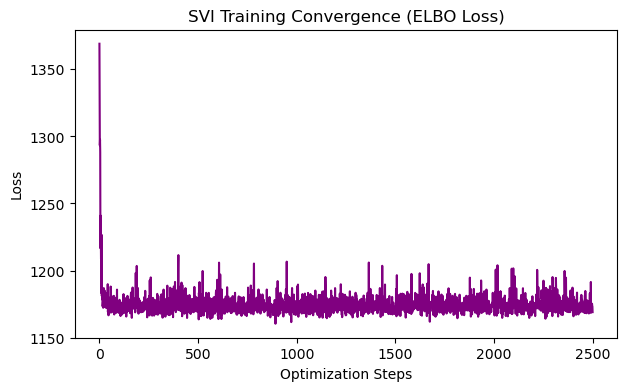

In [26]:
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import numpy as np

# In case the connection got closed earlier, re-establish it safely:
try:
    conn.execute("SELECT 1")
except Exception:
    conn = sqlite3.connect(str(db_path))

# 1. Fetch a clean, single-season dataset to train the model quickly
train_query = """
    SELECT HT.team_long_name AS home_team,
           AT.team_long_name AS away_team,
           home_team_goal, 
           away_team_goal
    FROM Match
    JOIN League ON League.id = Match.league_id
    JOIN Team AS HT ON HT.team_api_id = Match.home_team_api_id
    JOIN Team AS AT ON AT.team_api_id = Match.away_team_api_id
    WHERE League.name = 'England Premier League' AND season = '2015/2016';
"""
train_df = pd.read_sql(train_query, conn)

print(f"Loaded {len(train_df)} matches from the EPL 15/16 season.")

# 2. Encode team names to integer IDs (0 to 19)
teams = pd.unique(train_df[['home_team', 'away_team']].values.ravel('K'))
team_to_id = {team: i for i, team in enumerate(teams)}
id_to_team = {i: team for team, i in team_to_id.items()}

# Redefine the global n_teams based on our actual dataset (EPL has 20)
n_teams = len(teams)

# 3. Create PyTorch Tensors
home_team_ids_t = torch.tensor(train_df['home_team'].map(team_to_id).values, dtype=torch.long)
away_team_ids_t = torch.tensor(train_df['away_team'].map(team_to_id).values, dtype=torch.long)
home_goals_t = torch.tensor(train_df['home_team_goal'].values, dtype=torch.float)
away_goals_t = torch.tensor(train_df['away_team_goal'].values, dtype=torch.float)

# 4. Setup SVI (Stochastic Variational Inference)
pyro.clear_param_store() # Clear parameters if you re-run this cell

# We use an AutoGuide which automatically constructs a Mean-Field variational distribution
guide = AutoDiagonalNormal(soccer_model)

# Define optimizer and loss function (Evidence Lower Bound - ELBO)
optimizer = Adam({"lr": 0.05})
svi = SVI(soccer_model, guide, optimizer, loss=Trace_ELBO())

# 5. Training Loop
n_steps = 2500
losses = []

print("Training the Bayesian Poisson Model...")
for step in range(n_steps):
    # Pass our data tensors into the setup
    loss = svi.step(home_team_ids_t, away_team_ids_t, home_goals_t, away_goals_t)
    losses.append(loss)
    if step % 500 == 0:
        print(f"Step {step} - ELBO Loss: {loss:.2f}")

print(f"Training complete! Final Step {n_steps} - ELBO Loss: {loss:.2f}")

# Plot the training loss trajectory
plt.figure(figsize=(7, 4))
plt.plot(losses, color='purple')
plt.title("SVI Training Convergence (ELBO Loss)")
plt.xlabel("Optimization Steps")
plt.ylabel("Loss")
plt.show()

### Extracting the Learned Parameters
Now that our model converged, we can extract the inferred "Attack" and "Defense" parameters for each team. Instead of exact point estimates (like a Neural Network would give), SVI gives us probability distributions (means and scales). Let's plot the mean Attack and Defense strengths.

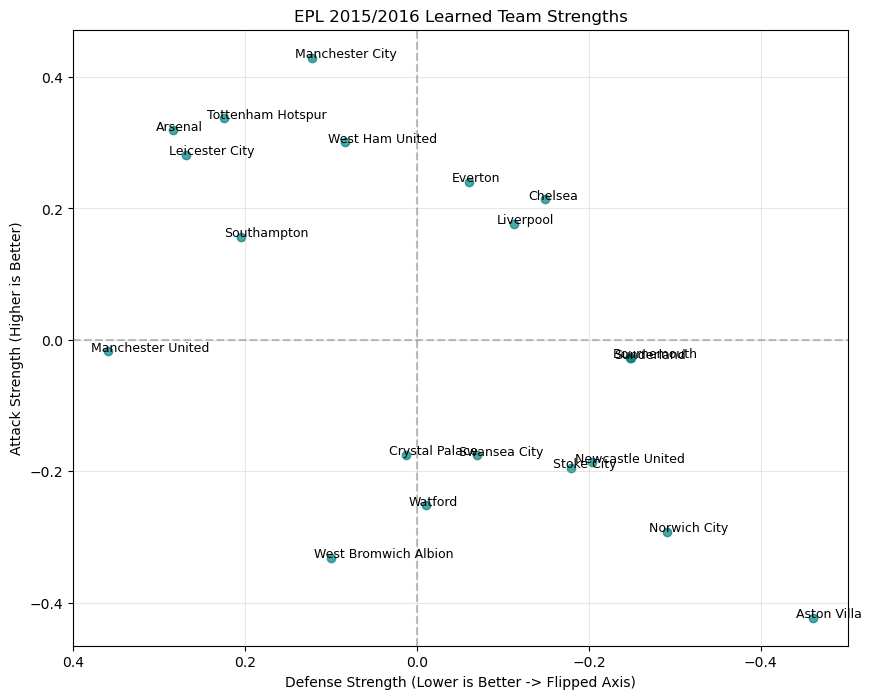

In [27]:
# Wait for the model parameters to be extracted
# We can grab our approximate posterior distributions (the "guide")
quantiles = guide.quantiles([0.5])  # Just grab the median as our point estimate for plotting

# Extract params
post_attack = quantiles["attack"][0].detach().numpy()
post_defense = quantiles["defense"][0].detach().numpy()

# Compile them into a readable pandas DataFrame
strength_df = pd.DataFrame({
    'Team': [id_to_team[i] for i in range(n_teams)],
    'Attack_Strength': post_attack,
    'Defense_Strength': post_defense
})

# Note on Defense: lower values mean feWER goals conceded! 
# So a "strong" defense is mathematically a low or negative number in this setup.

# Plot Attack vs Defense (Flipped defense axis so top right is the best!)
plt.figure(figsize=(10, 8))
plt.scatter(strength_df['Defense_Strength'], strength_df['Attack_Strength'], color='teal', alpha=0.7)

for i in range(strength_df.shape[0]):
    row = strength_df.iloc[i]
    plt.text(row['Defense_Strength'] + 0.02, row['Attack_Strength'], row['Team'], fontsize=9)

# We want the best defenses (lowest values) to be on the right side of the graph
plt.gca().invert_xaxis()

plt.title("EPL 2015/2016 Learned Team Strengths")
plt.xlabel("Defense Strength (Lower is Better -> Flipped Axis)")
plt.ylabel("Attack Strength (Higher is Better)")
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Close the database safely!
conn.close()

## 13. Interpreting the Results and Next Steps

### What do we see in this plot?
The scatter plot visualizes the latent **Attack** and **Defense** parameters our Bayesian model learned from the 2015/2016 EPL season. 
*(Note: Mathematically in our equation `... - def_away`, a more **positive** defense value effectively subtracts from the opponent's expected goals, making it a stronger defense. By inverting the X-axis, the top-left quadrant represents the best teams).*

1. **The Champions & Contenders (Top Left):** 
   - **Leicester City**, **Arsenal**, **Tottenham**, and **Manchester City** sit high up and to the left. They had the strongest combinations of goal-scoring prowess (high attack) and goal prevention (high defense).
2. **The Relegated (Bottom Right):** 
   - **Aston Villa** is completely isolated at the bottom right. The model recognized them as having an abysmal attack and the leakiest defense in the league (which maps perfectly to reality, as they finished dead last with 17 points).
3. **The Defensive Stalwarts with No Bite (Middle Left):**
   - **Manchester United** is shown to have an exceptionally strong defense (far left) but an attack hovering slightly below average (around 0.0). This perfectly captures Louis van Gaal's notoriously rigid 15/16 team that kept many clean sheets but struggled to score!

---

### What else can we do with this? (Next Steps for MBML)

Now that you have a functioning baseline Bayesian model, you can elevate the project by adding complexity. Here are the best next steps:

#### 1. Posterior Predictive Checks & Season Simulation
- **The Idea:** Instead of just looking at the `median` parameters, sample from your entire posterior distribution to **simulate the entire season 10,000 times**. 
- **The Output:** You can generate a probabilistic final league table. E.g., "Leicester City had a 15% probability of winning the league, Arsenal 45%".

#### 2. Incorporate "Form" (Dynamic Latent Variables)
- **The Limit of this Model:** Right now, a team has one static `attack` stat for the whole 38-game season. 
- **The Enhancement:** Use a **Gaussian Random Walk** for the attack/defense variables so they can shift week-to-week based on team "form" or manager sackings. 

#### 3. Integrate the FIFA Player Attributes
- **The Limit of this Model:** The model only uses the final scores to learn team strength. It ignores the actual players on the pitch.
- **The Enhancement:** Make the latent `attack` parameter a function of the EA Sports FIFA ratings. E.g., `Team Attack = weights * (Average Striker FIFA Rating + Average Midfielder Passing)`. Does having a 90-rated striker actually increase the Bayesian attack parameter?

#### 4. The Ultimate Test: Value Betting (ROI Simulation)
- **The Idea:** For every match in the dataset, use your model's posteriors to calculate the probability of a Home Win, Draw, or Away Win. 
- **The Enhancement:** Compare your probabilities to the `B365` odds. If your model says Arsenal has an 80% chance to win, but the bookies' odds imply a 50% chance, your model flags a "Value Bet". Simulate betting £10 on every value bet across the season and calculate your total Return on Investment (ROI)!

## 14. Predicting the Final Table (Monte Carlo Simulation)

Let's act on the first "next step" idea: simulating the entire season using our learned Bayesian parameters.

By sampling repeatedly from the learned distributions (the parameter medians, for simplicity here, though full Bayesian treatment would sample from the full posterior distributions), we can determine how many goals each team *would* score in every possible matchup. Since a football match uses discrete states (a team scores 0, 1, 2, 3... goals), we can run the league 1,000 times!

This will allow us to estimate the probabilistic final ranking (e.g., "Leicester City wins 25% of the simulations, Arsenal wins 40%").

Simulating the EPL season 1000 times based on learned latent parameters...


C:\Users\Madsl\AppData\Local\Temp\ipykernel_27936\933297830.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probs, y=teams_lbl, palette="magma")


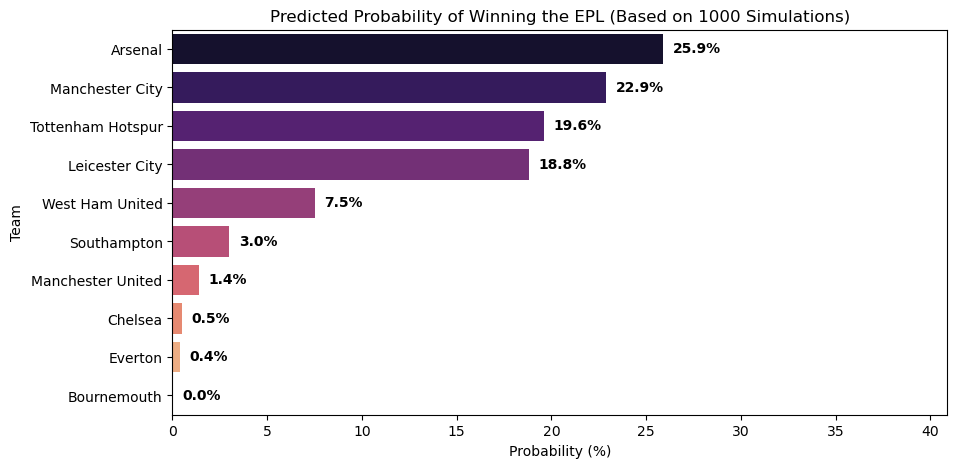

In [28]:
import numpy as np

# 1. Grab Point Estimates needed for expected goals (Lambda)
post_intercept = quantiles["intercept"].detach().numpy()[0]
post_home_adv = quantiles["home_adv"].detach().numpy()[0]

num_simulations = 1000
team_points = {team: np.zeros(num_simulations) for team in teams}

print(f"Simulating the EPL season {num_simulations} times based on learned latent parameters...")

for sim in range(num_simulations):
    # For a full league season, every team plays every other team Home and Away (38 games)
    for home_id in range(n_teams):
        for away_id in range(n_teams):
            if home_id == away_id:
                continue # Teams don't play themselves
            
            home_team_str = id_to_team[home_id]
            away_team_str = id_to_team[away_id]
            
            # Reconstruct Lambda (Expected Goals)
            log_lamb_home = post_intercept + post_home_adv + post_attack[home_id] - post_defense[away_id]
            log_lamb_away = post_intercept + post_attack[away_id] - post_defense[home_id]
            
            lamb_home = np.exp(log_lamb_home)
            lamb_away = np.exp(log_lamb_away)
            
            # Sample actual goals from the Poisson distribution using the rates
            # (In a fully Bayesian setup, you would sample the parameters from the guide too!)
            sim_home_goals = np.random.poisson(lamb_home)
            sim_away_goals = np.random.poisson(lamb_away)
            
            # Award points
            if sim_home_goals > sim_away_goals:
                team_points[home_team_str][sim] += 3
            elif sim_home_goals < sim_away_goals:
                team_points[away_team_str][sim] += 3
            else:
                team_points[home_team_str][sim] += 1
                team_points[away_team_str][sim] += 1

# Calculate the probability that each team wins the league across the simulations
champion_counts = {team: 0 for team in teams}

for sim in range(num_simulations):
    # Find the team with the max points in this simulation iteration
    sim_table = {team: team_points[team][sim] for team in teams}
    champion = max(sim_table, key=sim_table.get)
    champion_counts[champion] += 1

# Convert to probabilities
win_probs = {team: (count / num_simulations) * 100 for team, count in champion_counts.items()}
win_probs_sorted = dict(sorted(win_probs.items(), key=lambda item: item[1], reverse=True))

# 2. Visualize the Title Probabilities
teams_lbl = list(win_probs_sorted.keys())[:10]  # Show top 10
probs = list(win_probs_sorted.values())[:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=probs, y=teams_lbl, palette="magma")
plt.title(f"Predicted Probability of Winning the EPL (Based on {num_simulations} Simulations)")
plt.xlabel("Probability (%)")
plt.ylabel("Team")

# Annotate bars
for i, v in enumerate(probs):
    plt.text(v + 0.5, i + 0.1, f"{v:.1f}%", color='black', fontweight='bold')

plt.xlim(0, max(probs) + 15)
plt.show()

## 15. Model Comparison: Bayesian approaches vs Simple MLE (Maximum Likelihood Estimation)

To truly appreciate the value of our Model-Based Machine Learning (Bayesian) approach, we should compare it to a standard frequentist approach—a simple Poisson Generalized Linear Model (GLM) solved via Maximum Likelihood Estimation (MLE).

**Why compare?**
- **MLE (Frequentist):** Finds the exact parameters that maximize the likelihood of the observed data. It yields point estimates (no uncertainty/distribution). It is also prone to overfitting (e.g., if a team scores 5 goals from 2 shots, MLE assumes they are exceptionally lethal, whereas a Bayesian approach shrinks this anomaly back to the mean using the prior).
- **Pyro (Bayesian):** Uses priors to regularize the model and produces full posterior distributions, allowing us to quantify our uncertainty.

We can fit the exact same model equation using `statsmodels`. First, we reshape the dataset so each row is a single team's goal-scoring performance in a match.

Reshaped Data Head (for MLE):


,team,opponent,goals,home
0,Arsenal,West Ham United,0,1
1,Bournemouth,Aston Villa,0,1
2,Chelsea,Swansea City,2,1
3,Everton,Watford,2,1
4,Leicester City,Sunderland,4,1


Optimization terminated successfully.
         Current function value: 1.424561
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:                  goals   No. Observations:                  760
Model:                        Poisson   Df Residuals:                      720
Method:                           MLE   Df Model:                           39
Date:                 lø, 25 apr 2026   Pseudo R-squ.:                 0.05460
Time:                        12:57:53   Log-Likelihood:                -1082.7
converged:                       True   LL-Null:                       -1145.2
Covariance Type:            nonrobust   LLR p-value:                 6.007e-11
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.0713      0.213      0.33

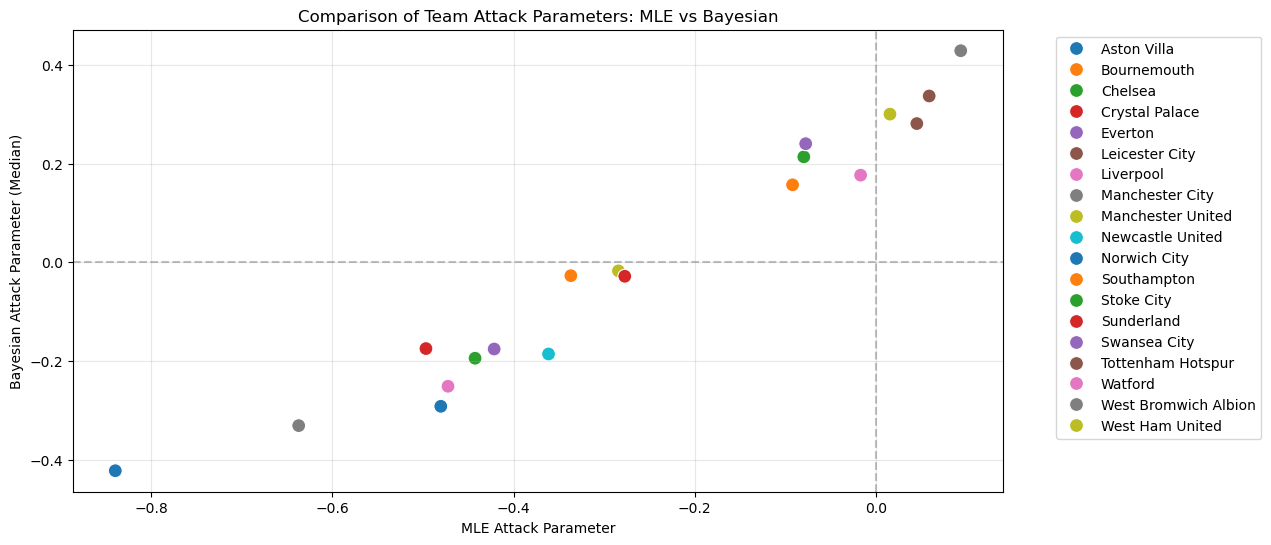

In [31]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Reshape the match dataset to a long format for statsmodels
# We need every row to represent ONE team's goals against ONE opponent.
goal_data = pd.concat([
    train_df[['home_team', 'away_team', 'home_team_goal']].assign(home=1).rename(
        columns={'home_team': 'team', 'away_team': 'opponent', 'home_team_goal': 'goals'}
    ),
    train_df[['away_team', 'home_team', 'away_team_goal']].assign(home=0).rename(
        columns={'away_team': 'team', 'home_team': 'opponent', 'away_team_goal': 'goals'}
    )
], ignore_index=True)

print("Reshaped Data Head (for MLE):")
display(goal_data.head())

# 2. Fit the Poisson GLM (Maximum Likelihood Estimation)
# Formula: Goals ~ Home Advantage + Team Attack (team) + Opponent Defense (opponent)
# Note: Statsmodels will automatically drop one dummy variable for `team` and `opponent` 
# (e.g., 'Arsenal') to serve as the baseline/intercept category.
mle_model = smf.poisson(formula="goals ~ home + team + opponent", data=goal_data)
mle_result = mle_model.fit()

# 3. Print the MLE summary
print(mle_result.summary())

# 4. Compare Home Advantage directly
# The Bayesian point estimate (median):
print(f"\nBayesian Home Advantage (SVI Median): {post_home_adv:.4f}")

# The MLE point estimate:
mle_home_adv = mle_result.params['home']
mle_home_adv_stderr = mle_result.bse['home']
print(f"MLE Home Advantage: {mle_home_adv:.4f} (SE: {mle_home_adv_stderr:.4f})")

print("\nNotice how the MLE model gives us point estimates and Standard Errors (derived under asymptotic assumptions),")
print("while the Bayesian model (Pyro) directly outputs full, valid posterior probability distributions!")


# plot some of the team attack parameters from MLE vs Bayesian
# Extract MLE attack parameters (excluding the baseline team)
# Use .index to iterate over parameter names instead of values
mle_attack_params = {param: mle_result.params[param] for param in mle_result.params.index
    if param.startswith('team') and param != 'team[T.Arsenal]'}  # Assuming Arsenal is the baseline
# Extract Bayesian attack parameters (median)
bayes_attack_params = {id_to_team[i]: post_attack[i] for i in range(n_teams)}
# Combine into a DataFrame for plotting
# Note: we need to clean up the param name string to match the team names
def extract_team_name(param_str):
    # e.g., 'team[T.Aston Villa]' -> 'Aston Villa'
    return param_str.replace('team[T.', '').replace(']', '')

comparison_df = pd.DataFrame({
    'Team': [extract_team_name(p) for p in mle_attack_params.keys()],
    'MLE_Attack': list(mle_attack_params.values()),
    'Bayesian_Attack': [bayes_attack_params[extract_team_name(p)] for p in mle_attack_params.keys()]
})
# Plotting the comparison
plt.figure(figsize=(12, 6))
sns.scatterplot(x='MLE_Attack', y='Bayesian_Attack', data=comparison_df, hue='Team', palette='tab10', s=100)
plt.title("Comparison of Team Attack Parameters: MLE vs Bayesian")
plt.xlabel("MLE Attack Parameter")
plt.ylabel("Bayesian Attack Parameter (Median)")
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()
